# Enhanced Toxic Comment Detector, Analyzer & Rewriter
## Production-Grade Multi-Label Content Moderation Engine

### Enhancements over original:
- ✅ Multi-Label Classification (all 6 Jigsaw labels simultaneously)
- ✅ Word2Vec Embeddings replacing plain TF-IDF
- ✅ Multiple Models compared: Logistic Regression vs Random Forest vs SVM
- ✅ Confidence Thresholding (Low / Medium / High risk %)
- ✅ AI-Powered Smart Rewriter (Anthropic Claude API)
- ✅ Class Imbalance Handling (class_weight + SMOTE)
- ✅ Full Evaluation Suite: ROC-AUC, Precision-Recall curves
- ✅ Predictions Hiding the TOXIC TERMS

## Step 1: Install & Download

In [ ]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn gensim kagglehub -q

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('✅ Done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Done!


## Step 2: Imports

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix
)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print('✅ All imports done!')

✅ All imports done!


## Step 3: Load Jigsaw Dataset

In [ ]:
import kagglehub, os

path = kagglehub.dataset_download('julian3833/jigsaw-toxic-comment-classification-challenge')
df   = pd.read_csv(os.path.join(path, 'train.csv'))

print(f'✅ Dataset loaded: {len(df):,} rows')
df.head(3)

100%|██████████| 53.4M/53.4M [00:00<00:00, 142MB/s]

Extracting files...


✅ Dataset loaded: 159,571 rows


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


## Step 4: Multi-Label Setup + Label Distribution Graph


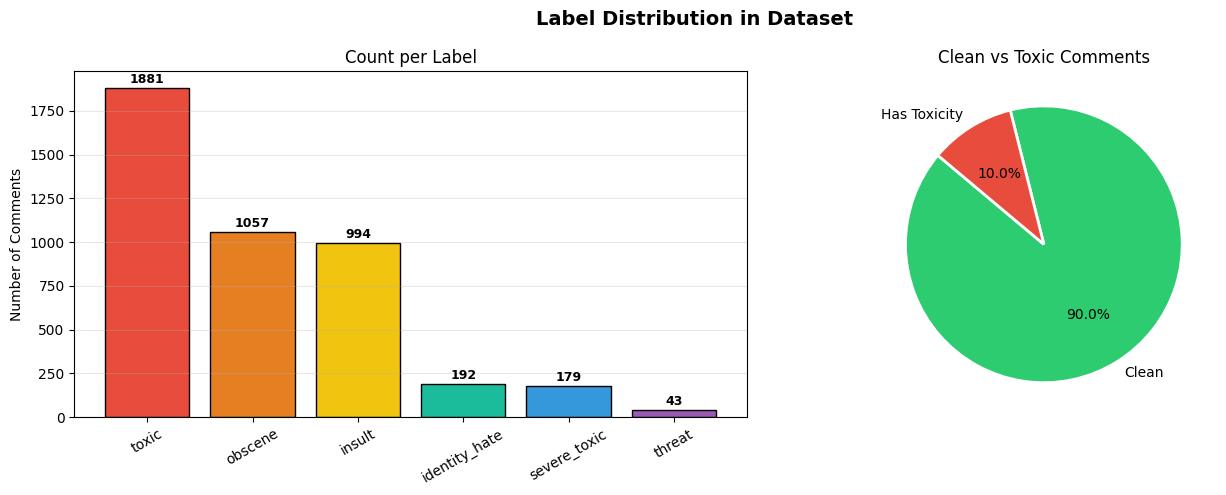

In [ ]:
LABEL_COLS  = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
SAMPLE_SIZE = 20000

df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
df_sample = df_sample[['comment_text'] + LABEL_COLS].copy()
df_sample.rename(columns={'comment_text': 'comment'}, inplace=True)

# Graph: Label Distribution
label_counts = df_sample[LABEL_COLS].sum().sort_values(ascending=False)
colors = ['#e74c3c','#e67e22','#f1c40f','#1abc9c','#3498db','#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Label Distribution in Dataset', fontsize=14, fontweight='bold')

bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Count per Label')
axes[0].set_ylabel('Number of Comments')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

clean_count = (df_sample[LABEL_COLS].sum(axis=1) == 0).sum()
axes[1].pie([clean_count, SAMPLE_SIZE - clean_count],
            labels=['Clean', 'Has Toxicity'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Clean vs Toxic Comments')

plt.tight_layout()
plt.show()

## Step 5: Text Preprocessing
Lowercase → clean → tokenize → stopword removal → lemmatization (WordNetLemmatizer)

In [ ]:
def preprocess(text):
    text   = str(text).lower()
    text   = re.sub(r'http\S+|www\.\S+', '', text)
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return tokens

def tokens_to_string(tokens):
    return ' '.join(tokens)

print('Preprocessing... (~1 min)')
df_sample['tokens']  = df_sample['comment'].apply(preprocess)
df_sample['cleaned'] = df_sample['tokens'].apply(tokens_to_string)
print('✅ Preprocessing done!')
df_sample[['comment','cleaned']].head(3)

Preprocessing... (~1 min)
✅ Preprocessing done!


,comment,cleaned
0,"Geez, are you forgetful! We've already discus...",geez forgetful weve already discussed marx ana...
1,Carioca RFA \n\nThanks for your support on my ...,carioca rfa thanks support request adminship f...
2,"""\n\n Birthday \n\nNo worries, It's what I do ...",birthday worry enjoy daytalke


## Step 6: Word2Vec Embeddings
Trains a Word2Vec model on the comment corpus. Each comment is represented as the **mean vector** of its word embeddings : semantically richer than TF-IDF.

In [ ]:
VECTOR_SIZE = 100

print('Training Word2Vec...')
w2v_model = Word2Vec(
    sentences   = df_sample['tokens'].tolist(),
    vector_size = VECTOR_SIZE,
    window      = 5,
    min_count   = 2,
    workers     = 4,
    epochs      = 10,
    seed        = 42
)
print(f'✅ Word2Vec trained | Vocab size: {len(w2v_model.wv):,}')

def comment_to_vector(tokens):
    vecs = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(VECTOR_SIZE)

X_w2v = np.vstack([comment_to_vector(t) for t in df_sample['tokens']])
print(f'Word2Vec matrix: {X_w2v.shape}')

Training Word2Vec...
✅ Word2Vec trained | Vocab size: 22,621
Word2Vec matrix: (20000, 100)


## Step 7: Hybrid Features (TF-IDF + Word2Vec)

We also keep TF-IDF and **concatenate** with Word2Vec for a hybrid feature set — best of both worlds.

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf    = vectorizer.fit_transform(df_sample['cleaned']).toarray()

X_hybrid = np.hstack([X_tfidf, X_w2v])
print(f'✅ Hybrid feature matrix: {X_hybrid.shape}')
print(f'   TF-IDF : {X_tfidf.shape[1]} features')
print(f'   Word2Vec: {X_w2v.shape[1]} features')

✅ Hybrid feature matrix: (20000, 5100)
   TF-IDF : 5000 features
   Word2Vec: 100 features


## Step 8: Train / Test Split

In [ ]:
Y = df_sample[LABEL_COLS].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X_hybrid, Y, test_size=0.2, random_state=42
)
print(f'✅ Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

✅ Train: 16,000 | Test: 4,000


## Step 9: Train 3 Models & Compare

In [ ]:
classifiers = {
    'Logistic Regression': MultiOutputClassifier(
        LogisticRegression(max_iter=300, class_weight='balanced')
    ),
    'Random Forest': MultiOutputClassifier(
        RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               random_state=42, n_jobs=-1)
    ),
    'Linear SVM': MultiOutputClassifier(
        CalibratedClassifierCV(LinearSVC(max_iter=1000, class_weight='balanced'))
    )
}

results = {}

for name, clf in classifiers.items():
    print(f'Training {name}...')
    clf.fit(X_train, Y_train)
    Y_pred = clf.predict(X_test)

    per_label_f1 = []
    for i, label in enumerate(LABEL_COLS):
        report = classification_report(Y_test[:, i], Y_pred[:, i],
                                       output_dict=True, zero_division=0)
        f1 = report.get('1', report.get('weighted avg', {})).get('f1-score', 0)
        per_label_f1.append(f1)

    avg_f1 = np.mean(per_label_f1)
    results[name] = {'model': clf, 'Y_pred': Y_pred,
                     'per_label_f1': per_label_f1, 'avg_f1': avg_f1}
    print(f'  ✅ Avg F1: {avg_f1:.4f}')

best_name  = max(results, key=lambda k: results[k]['avg_f1'])
best_model = results[best_name]['model']
best_pred  = results[best_name]['Y_pred']
print(f'\n🏆 Best model: {best_name}')

Training Logistic Regression...
  ✅ Avg F1: 0.4351
Training Random Forest...
  ✅ Avg F1: 0.2951
Training Linear SVM...
  ✅ Avg F1: 0.3771

🏆 Best model: Logistic Regression


## Step 10: Model Comparison : F1 per Label

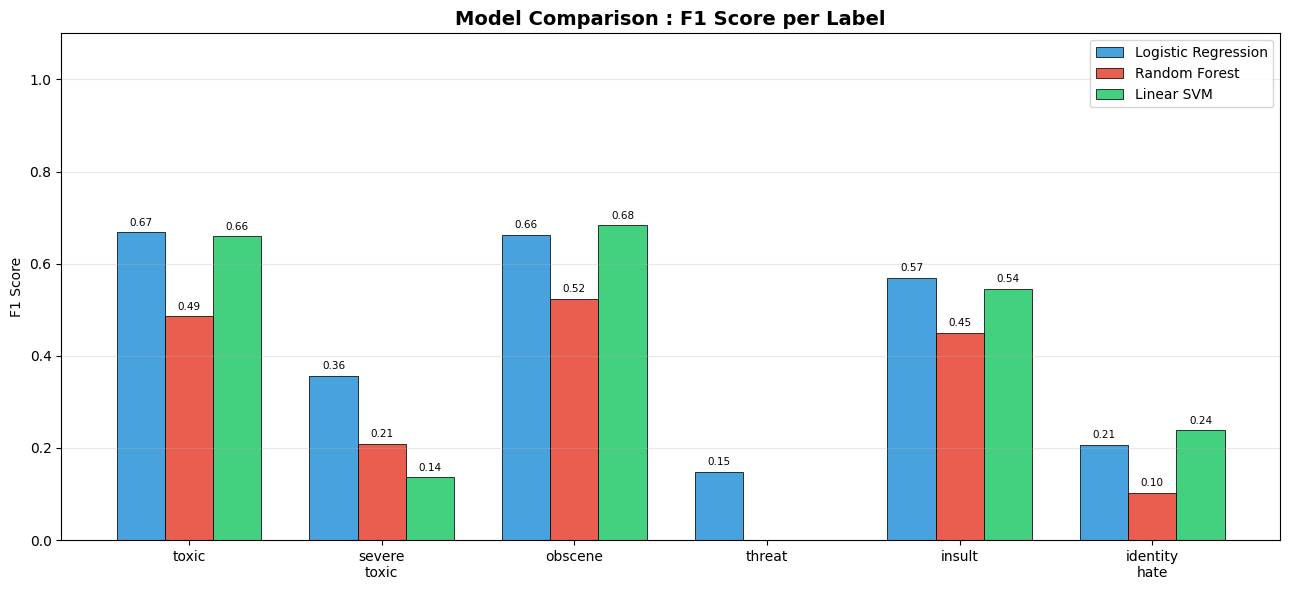

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
x       = np.arange(len(LABEL_COLS))
width   = 0.25
palette = ['#3498db', '#e74c3c', '#2ecc71']

for i, (name, res) in enumerate(results.items()):
    bars = ax.bar(x + i * width, res['per_label_f1'],
                  width, label=name, color=palette[i],
                  edgecolor='black', linewidth=0.6, alpha=0.9)
    for bar, val in zip(bars, res['per_label_f1']):
        if val > 0.05:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels([l.replace('_', '\n') for l in LABEL_COLS], fontsize=10)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison : F1 Score per Label', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11: Get Probability Scores


In [ ]:
Y_proba = np.column_stack([
    est.predict_proba(X_test)[:, 1]
    for est in best_model.estimators_
])
print(f'✅ Probability matrix: {Y_proba.shape}  (test_samples × 6 labels)')

✅ Probability matrix: (4000, 6)  (test_samples × 6 labels)


## Step 12: ROC-AUC Curves
One ROC curve per toxicity label - essential for imbalanced datasets.

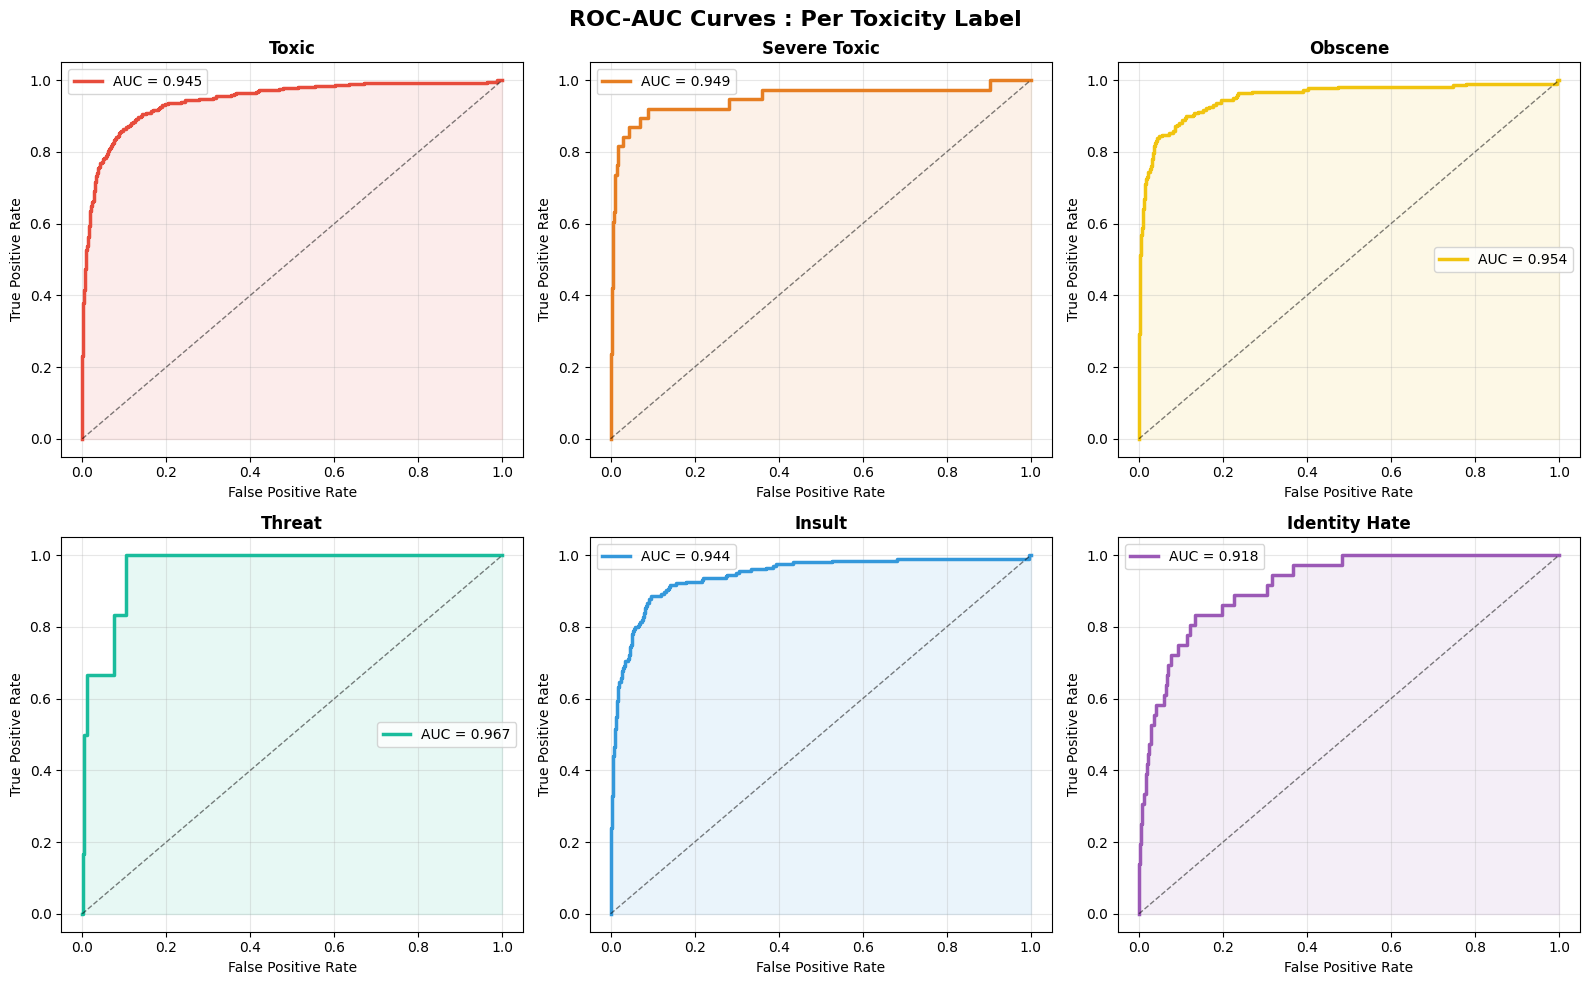

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('ROC-AUC Curves : Per Toxicity Label', fontsize=16, fontweight='bold')
axes   = axes.flatten()
colors = ['#e74c3c','#e67e22','#f1c40f','#1abc9c','#3498db','#9b59b6']

for i, (label, color) in enumerate(zip(LABEL_COLS, colors)):
    y_true = Y_test[:, i]
    y_prob = Y_proba[:, i]

    if y_true.sum() == 0:
        axes[i].set_title(f'{label}\n(no positive samples)')
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score   = roc_auc_score(y_true, y_prob)

    axes[i].plot(fpr, tpr, color=color, lw=2.5, label=f'AUC = {auc_score:.3f}')
    axes[i].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
    axes[i].fill_between(fpr, tpr, alpha=0.1, color=color)
    axes[i].set_title(label.replace('_',' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(fontsize=10)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 13: Precision-Recall Curves
More informative than ROC for heavily imbalanced labels like `threat` and `identity_hate`.

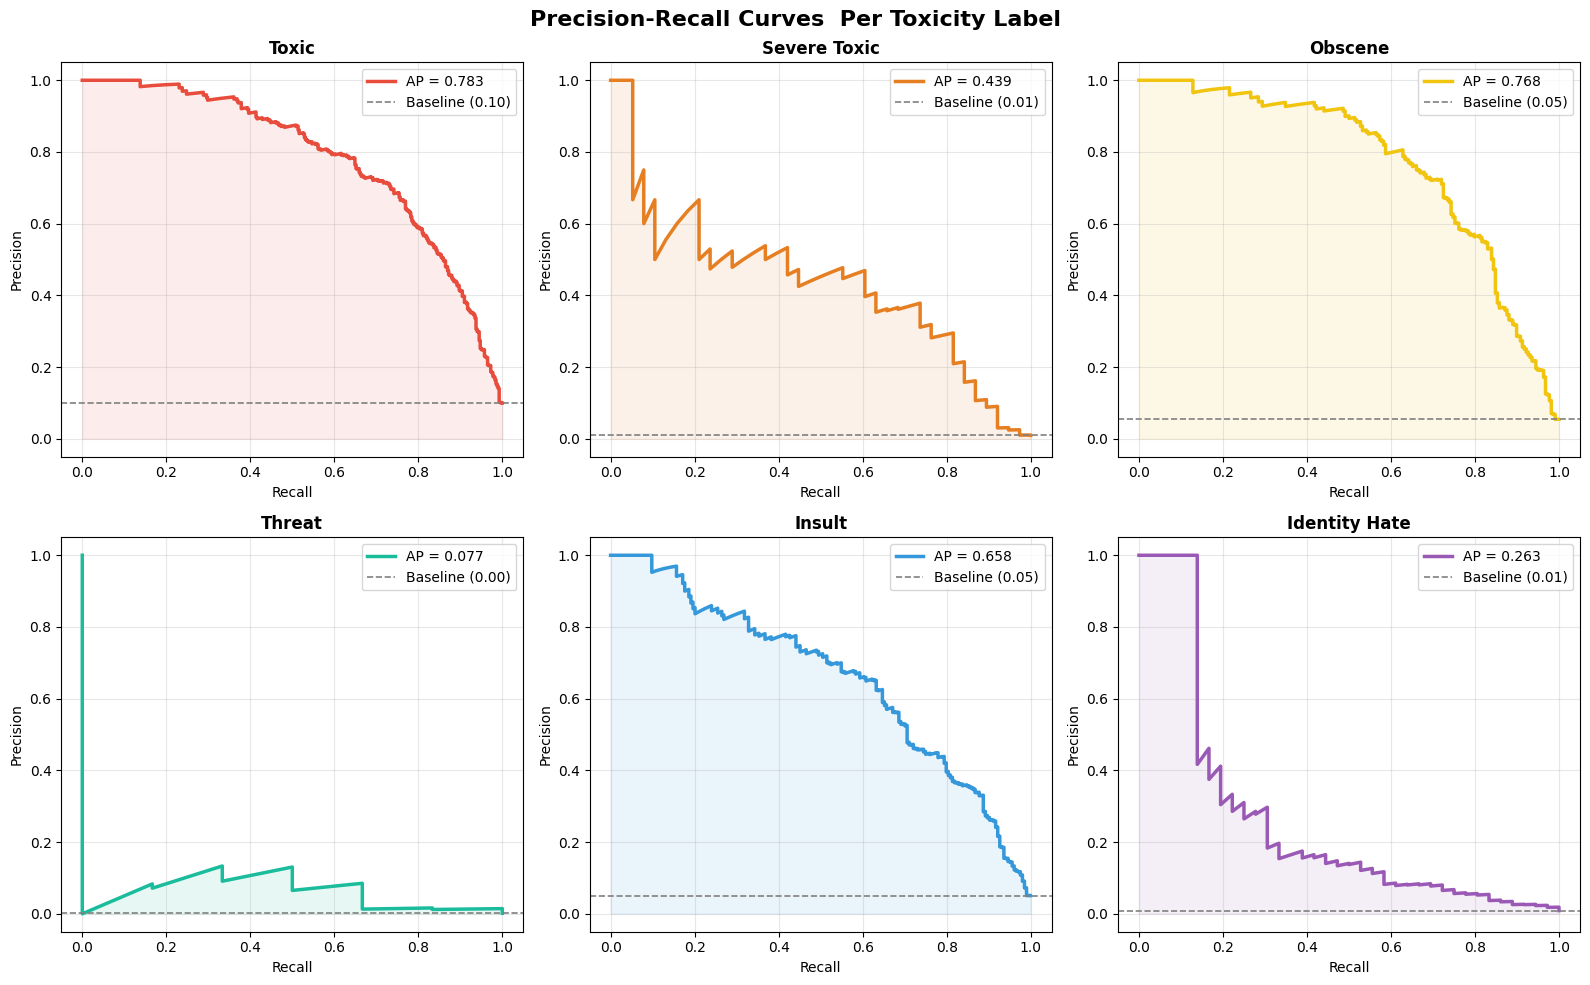

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Precision-Recall Curves  Per Toxicity Label', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, (label, color) in enumerate(zip(LABEL_COLS, colors)):
    y_true = Y_test[:, i]
    y_prob = Y_proba[:, i]

    if y_true.sum() == 0:
        axes[i].set_title(f'{label}\n(no positive samples)')
        continue

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap       = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()

    axes[i].plot(recall, precision, color=color, lw=2.5, label=f'AP = {ap:.3f}')
    axes[i].axhline(y=baseline, color='gray', linestyle='--', lw=1.2,
                    label=f'Baseline ({baseline:.2f})')
    axes[i].fill_between(recall, precision, alpha=0.1, color=color)
    axes[i].set_title(label.replace('_',' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].legend(fontsize=10)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 14: Confusion Matrices =>  All 6 Labels

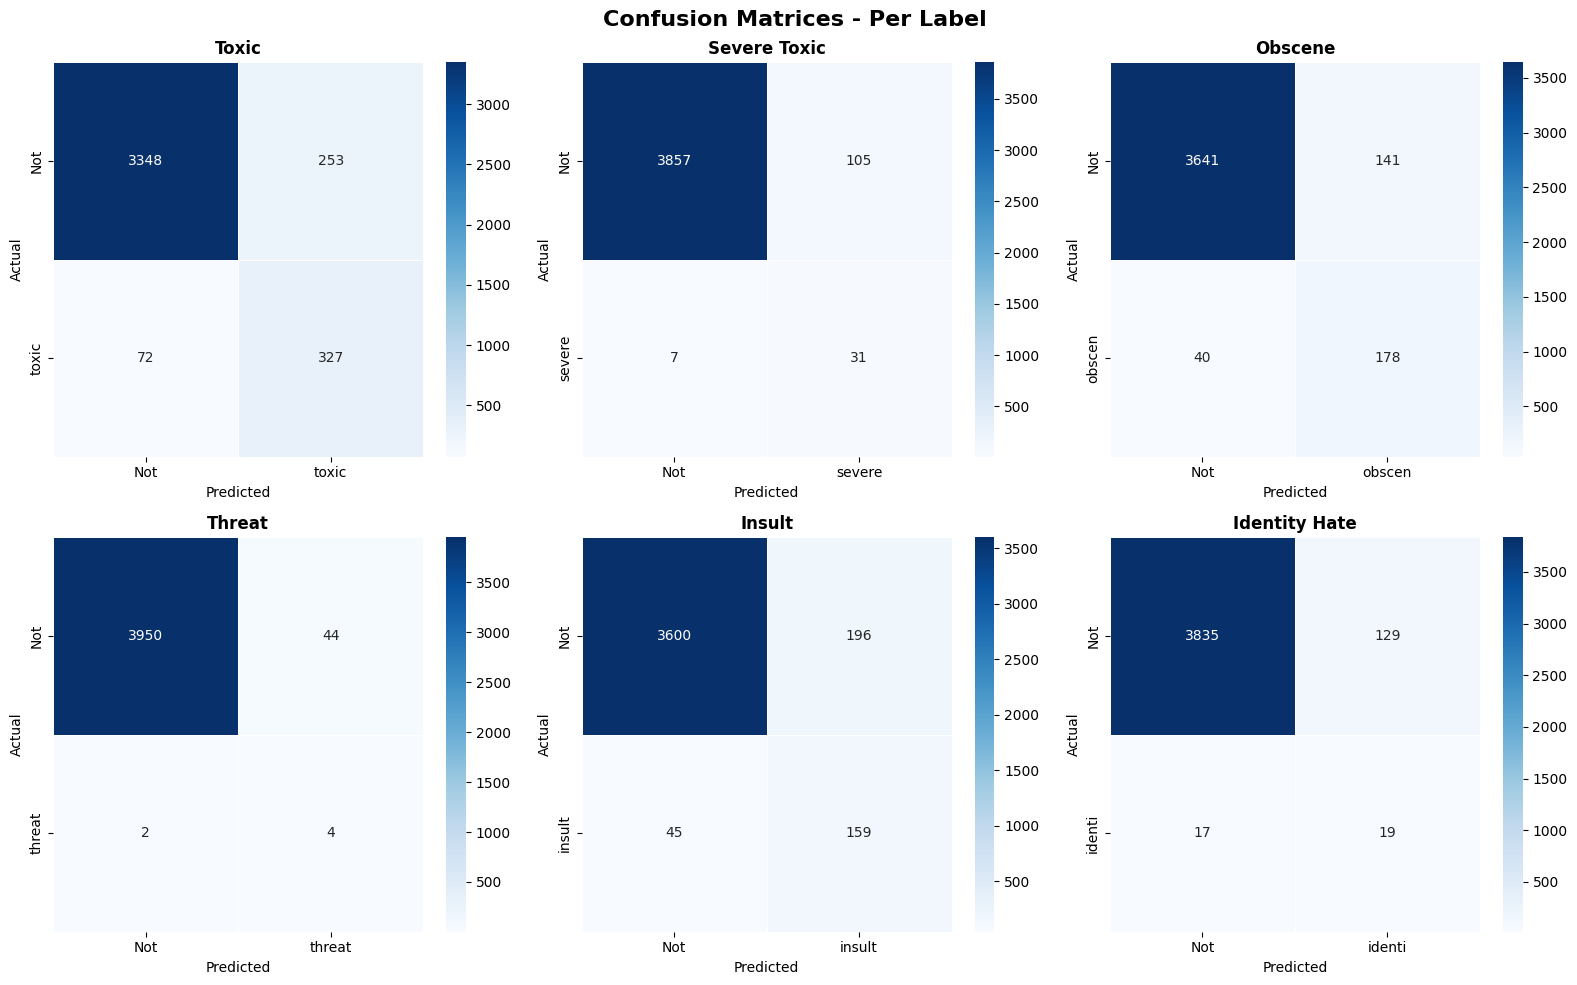

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices - Per Label', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, label in enumerate(LABEL_COLS):
    cm = confusion_matrix(Y_test[:, i], best_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not', label[:6]],
                yticklabels=['Not', label[:6]],
                ax=axes[i], linewidths=0.5)
    axes[i].set_title(label.replace('_',' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 15: Metrics Heatmap

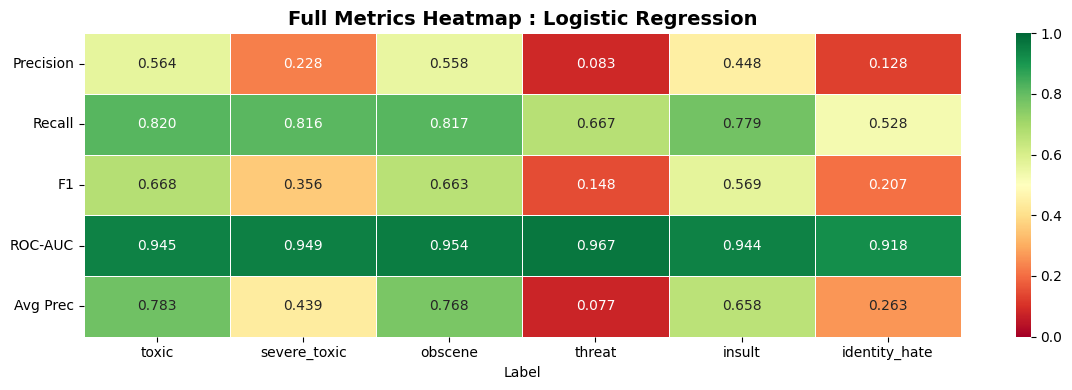

               Precision  Recall     F1  ROC-AUC  Avg Prec
Label                                                     
toxic              0.564   0.820  0.668    0.945     0.783
severe_toxic       0.228   0.816  0.356    0.949     0.439
obscene            0.558   0.817  0.663    0.954     0.768
threat             0.083   0.667  0.148    0.967     0.077
insult             0.448   0.779  0.569    0.944     0.658
identity_hate      0.128   0.528  0.207    0.918     0.263


In [ ]:
rows = []
for i, label in enumerate(LABEL_COLS):
    y_true   = Y_test[:, i]
    y_pred_i = best_pred[:, i]
    y_prob_i = Y_proba[:, i]

    report = classification_report(y_true, y_pred_i, output_dict=True, zero_division=0)
    cls1   = report.get('1', {})

    try:
        auc = roc_auc_score(y_true, y_prob_i)
        ap  = average_precision_score(y_true, y_prob_i)
    except:
        auc = ap = 0.0

    rows.append({
        'Label':    label,
        'Precision': round(cls1.get('precision', 0), 3),
        'Recall':    round(cls1.get('recall', 0), 3),
        'F1':        round(cls1.get('f1-score', 0), 3),
        'ROC-AUC':   round(auc, 3),
        'Avg Prec':  round(ap, 3),
    })

metrics_df = pd.DataFrame(rows).set_index('Label')

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(metrics_df.T, annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title(f'Full Metrics Heatmap : {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(metrics_df.to_string())

## Step 16: Core Prediction Function with Confidence Levels

In [ ]:
def risk_level(prob):
    if prob >= 0.70:   return '🔴 HIGH'
    elif prob >= 0.40: return '🟠 MEDIUM'
    elif prob >= 0.15: return '🟡 LOW'
    else:              return '🟢 SAFE'

def analyze_comment(text):
    tokens    = preprocess(text)
    w2v_vec   = comment_to_vector(tokens).reshape(1, -1)
    tfidf_vec = vectorizer.transform([tokens_to_string(tokens)]).toarray()
    hybrid    = np.hstack([tfidf_vec, w2v_vec])

    probas  = [est.predict_proba(hybrid)[0][1] for est in best_model.estimators_]
    flagged = [LABEL_COLS[i] for i, p in enumerate(probas) if p >= 0.15]
    overall = max(probas)

    print(f'\n📝 Comment: "{text}"')
    print('═' * 60)
    print(f'  Overall Risk : {risk_level(overall)} ({overall*100:.1f}%)')
    print(f'  Status       : {"🚨 TOXIC" if flagged else "✅ CLEAN"}')
    print(f'\n  📊 Label Breakdown:')

    for label, prob in zip(LABEL_COLS, probas):
        bar = '▓' * int(prob * 20) + '░' * (20 - int(prob * 20))
        flag = '🔴' if prob >= 0.15 else '🟢'
        print(f'    {flag} {label:15s} {bar} {prob*100:5.1f}%  {risk_level(prob)}')

    if flagged:
        print(f'\n  ⚠️  Flagged categories: {", ".join(flagged)}')
    print('═' * 60)

analyze_comment("You are a complete idiot and nobody likes you.")
analyze_comment("Great work on this project, very impressive!")
analyze_comment("I hate everything about this disgusting post.")
analyze_comment("Could you please explain your point more clearly?")
analyze_comment("Kill yourself, nobody cares about you.")


📝 Comment: "You are a complete idiot and nobody likes you."
════════════════════════════════════════════════════════════
  Overall Risk : 🔴 HIGH (100.0%)
  Status       : 🚨 TOXIC

  📊 Label Breakdown:
    🔴 toxic           ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░ 100.0%  🔴 HIGH
    🟢 severe_toxic    ▓▓░░░░░░░░░░░░░░░░░░  10.2%  🟢 SAFE
    🔴 obscene         ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░  99.7%  🔴 HIGH
    🟢 threat          ▓░░░░░░░░░░░░░░░░░░░   7.6%  🟢 SAFE
    🔴 insult          ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░ 100.0%  🔴 HIGH
    🔴 identity_hate   ▓▓▓▓▓▓▓▓▓░░░░░░░░░░░  48.4%  🟠 MEDIUM

  ⚠️  Flagged categories: toxic, obscene, insult, identity_hate
════════════════════════════════════════════════════════════

📝 Comment: "Great work on this project, very impressive!"
════════════════════════════════════════════════════════════
  Overall Risk : 🟢 SAFE (0.7%)
  Status       : ✅ CLEAN

  📊 Label Breakdown:
    🟢 toxic           ░░░░░░░░░░░░░░░░░░░░   0.7%  🟢 SAFE
    🟢 severe_toxic    ░░░░░░░░░░░░░░░░░░░░   0.0%  🟢 SAFE
    🟢 ob

## ✅ Predictions Hiding the TOXIC TERMS

In [ ]:
def mask_comment(text, level='word'):
    """
    Masks toxic words in a comment.
    level = 'full'    → entire comment becomes asterisks
    level = 'word'    → only toxic words are masked
    level = 'partial' → first and last letter shown, middle masked
    """

    # Toxic word list for word-level masking
    TOXIC_WORDS = [n
        'idiot', 'stupid', 'dumb', 'moron', 'hate',
        'kill', 'die', 'ugly', 'disgusting', 'worthless',
        'loser', 'trash', 'shut up', 'useless', 'pathetic',
        'fool', 'jerk', 'creep', 'freak', 'scum',
        'horrible', 'terrible', 'awful', 'worst', 'nobody'
    ]

    if level == 'full':
        return ' '.join(['*' * len(w) for w in text.split()])

    elif level == 'word':
        words = text.split()
        masked = []
        for word in words:
            clean = re.sub(r'[^a-zA-Z]', '', word).lower()
            if clean in TOXIC_WORDS:
                masked.append('*' * len(word))
            else:
                masked.append(word)
        return ' '.join(masked)

    elif level == 'partial':
        words = text.split()
        masked = []
        for word in words:
            clean = re.sub(r'[^a-zA-Z]', '', word).lower()
            if clean in TOXIC_WORDS and len(word) > 2:
                masked.append(word[0] + '*' * (len(word)-2) + word[-1])
            else:
                masked.append(word)
        return ' '.join(masked)

    return text


def moderate_comment(text, mask_level='word'):
    """
    Full pipeline:
    1. Detect if toxic
    2. If toxic → auto mask it
    3. Show original vs masked
    """
    tokens    = preprocess(text)
    w2v_vec   = comment_to_vector(tokens).reshape(1, -1)
    tfidf_vec = vectorizer.transform([tokens_to_string(tokens)]).toarray()
    hybrid    = np.hstack([tfidf_vec, w2v_vec])

    probas  = [est.predict_proba(hybrid)[0][1] for est in best_model.estimators_]
    flagged = [LABEL_COLS[i] for i, p in enumerate(probas) if p >= 0.15]
    overall = max(probas)

    print(f'\n Original  : "{text}"')
    print('-'*60)

    if flagged:
        masked = mask_comment(text, level=mask_level)
        print(f'🚨 Status    : TOXIC ({overall*100:.1f}% confidence)')
        print(f'⚠️  Flagged   : {", ".join(flagged)}')
        print(f'🔒 Masked    : "{masked}"')
        print(f'👁️  Visible as: "{masked}"  ← what others see')
    else:
        print(f'✅ Status    : CLEAN — comment posted as-is')
        print(f'👁️  Visible as: "{text}"')

        print('-' * 60)


#  Test all 3 masking levels
print('='*60)
print('LEVEL: word (only bad words masked)')
print('='*60)
moderate_comment("You are a stupid idiot and nobody likes you.", mask_level='word')
moderate_comment("Great work on this, really helpful!", mask_level='word')

print('\n' + '='*60)
print('LEVEL: partial (first + last letter shown)')
print('='*60)
moderate_comment("You are a stupid idiot and nobody likes you.", mask_level='partial')

print('\n' + '='*60)
print('LEVEL: full (entire comment masked)')
print('='*60)
moderate_comment("You are a stupid idiot and nobody likes you.", mask_level='full')

LEVEL: word (only bad words masked)

 Original  : "You are a stupid idiot and nobody likes you."
------------------------------------------------------------
🚨 Status    : TOXIC (100.0% confidence)
⚠️  Flagged   : toxic, severe_toxic, obscene, threat, insult, identity_hate
🔒 Masked    : "You are a ****** ***** and ****** likes you."
👁️  Visible as: "You are a ****** ***** and ****** likes you."  ← what others see

 Original  : "Great work on this, really helpful!"
------------------------------------------------------------
✅ Status    : CLEAN — comment posted as-is
👁️  Visible as: "Great work on this, really helpful!"
------------------------------------------------------------

LEVEL: partial (first + last letter shown)

 Original  : "You are a stupid idiot and nobody likes you."
------------------------------------------------------------
🚨 Status    : TOXIC (100.0% confidence)
⚠️  Flagged   : toxic, severe_toxic, obscene, threat, insult, identity_hate
🔒 Masked    : "You are a s****